In [1]:
!pip install -U datasets
!pip install fsspec==2023.9.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [2]:
from datasets import load_dataset

dataset = load_dataset("liar")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

liar.py:   0%|          | 0.00/6.41k [00:00<?, ?B/s]

The repository for liar contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/liar.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/10269 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1283 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1284 [00:00<?, ? examples/s]

In [3]:
# ---------- Cell 1: Mount Drive & Install Dependencies ----------
from google.colab import drive
drive.mount('/content/drive')

DRIVE_MODEL_PATH = "/content/drive/MyDrive/bert-fake-news"

!pip install -q transformers datasets scikit-learn torch

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.8 MB/s eta 0:00:00


In [4]:
# ---------- Cell 2: Fine‑Tune BERT on “liar” with Correct Label Mapping ----------
import os
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

# 1) Load & split the Hugging Face “liar” dataset (train + test)
#    Force download into /content/hf_cache so Colab can access it
dataset = load_dataset("liar", cache_dir="/content/hf_cache")
splits = dataset["train"].train_test_split(test_size=0.20, seed=42)

# 2) Correct label mapping: IDs 0, 1, 2 → “fake” (1); IDs 3, 4, 5 → “real” (0)
def simplify_label(example):
    example["label"] = int(example["label"] <= 2)
    return example

splits["train"] = splits["train"].map(simplify_label)
splits["test"]  = splits["test"].map(simplify_label)

# 3) Tokenize the “statement” field with BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_fn(examples):
    return tokenizer(
        examples["statement"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

splits["train"] = splits["train"].map(tokenize_fn, batched=True)
splits["test"]  = splits["test"].map(tokenize_fn, batched=True)

# 4) Tell 🤗 Datasets to return PyTorch tensors
splits["train"].set_format("torch", columns=["input_ids", "attention_mask", "label"])
splits["test"].set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 5) Load pretrained BERT for sequence classification (2 labels)
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

# 6) Prepare training arguments (save to Drive path)
os.makedirs(DRIVE_MODEL_PATH, exist_ok=True)
training_args = TrainingArguments(
    output_dir=DRIVE_MODEL_PATH,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir=f"{DRIVE_MODEL_PATH}/logs",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=splits["train"],
    eval_dataset=splits["test"],
)

# 7) Train!
trainer.train()

# 8) Save final model checkpoint into your Drive folder
trainer.save_model(DRIVE_MODEL_PATH)
tokenizer.save_pretrained(DRIVE_MODEL_PATH)

print("✅ Training complete. Model + tokenizer saved to:", DRIVE_MODEL_PATH)


Generating train split:   0%|          | 0/10269 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1283 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/8215 [00:00<?, ? examples/s]

Map:   0%|          | 0/2054 [00:00<?, ? examples/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kasibhatla-r (kasibhatla-r-ohio-state-buckeyes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,0.674900,0.681358
2,0.650900,0.687646
3,0.511800,0.834927


✅ Training complete. Model + tokenizer saved to: /content/drive/MyDrive/bert-fake-news


In [5]:
# ---------- Cell 1: Mount Drive & Install Dependencies ----------
from google.colab import drive
drive.mount('/content/drive')

DRIVE_MODEL_PATH = "/content/drive/MyDrive/bert-fake-news"

!pip install -q transformers datasets scikit-learn torch seaborn matplotlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


▶︎ Train size: 8215   ▶︎ Test size: 2054
▶︎ Class counts in train: {1: np.int64(4869), 0: np.int64(3346)}
▶︎ Class counts in test:  {1: np.int64(1218), 0: np.int64(836)}

=== Baseline (TF‑IDF + LR) ===
Accuracy: 0.5312
F1 Score:  0.5928

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.47      0.45       836
           1       0.61      0.58      0.59      1218

    accuracy                           0.53      2054
   macro avg       0.52      0.52      0.52      2054
weighted avg       0.54      0.53      0.53      2054



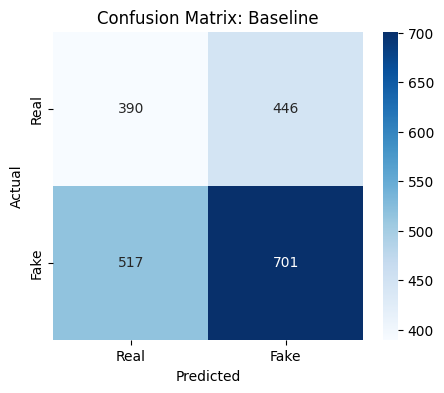

Map:   0%|          | 0/2054 [00:00<?, ? examples/s]


=== BERT (fine‑tuned) Quick Metrics ===
{'eval_loss': 0.8349273204803467, 'eval_model_preparation_time': 0.0027, 'eval_runtime': 14.1908, 'eval_samples_per_second': 144.742, 'eval_steps_per_second': 18.11}

=== BERT (fine‑tuned) Detailed Metrics ===
Accuracy: 0.5779
F1 Score:  0.6742

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.34      0.40       849
           1       0.62      0.74      0.67      1205

    accuracy                           0.58      2054
   macro avg       0.55      0.54      0.54      2054
weighted avg       0.56      0.58      0.56      2054



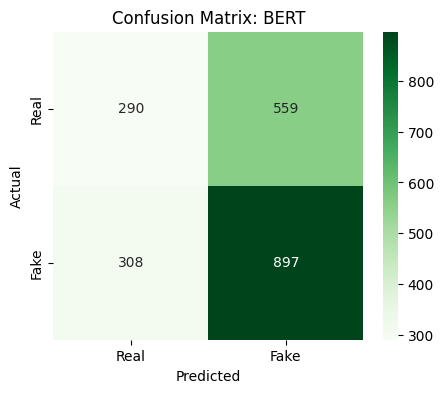

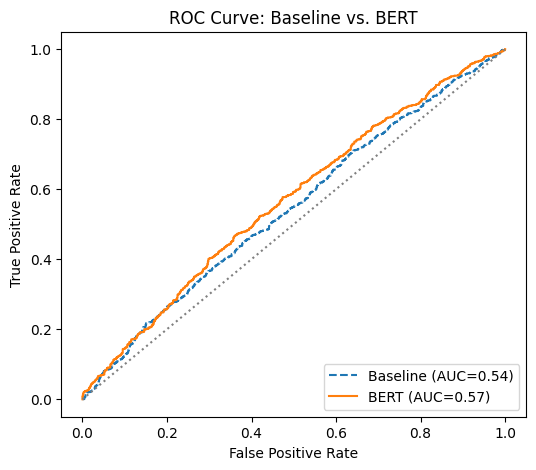


✅ Comparison metrics saved to /content/drive/MyDrive/bert-fake-news/comparison_metrics.json


In [7]:
# ---------- Cell 2: Recompute Baseline Metrics & Evaluate BERT ----------
import os
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# --------------------------------------------------------------
# 1) Reload “liar” into a DataFrame & create binary labels
dataset = load_dataset("liar", cache_dir="/content/hf_cache")
df = pd.DataFrame(dataset["train"])

df["label_bin"] = df["label"].apply(lambda x: int(x <= 2))

X_train, X_test, y_train, y_test = train_test_split(
    df["statement"],
    df["label_bin"],
    test_size=0.20,
    random_state=42,
    stratify=df["label_bin"]
)

print(f"▶︎ Train size: {len(X_train)}   ▶︎ Test size: {len(X_test)}")
print("▶︎ Class counts in train:", dict(pd.Series(y_train).value_counts()))
print("▶︎ Class counts in test: ", dict(pd.Series(y_test).value_counts()))

# --------------------------------------------------------------
# 2) (Re‑)Train TF‑IDF + Logistic Regression Baseline
baseline_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

baseline_pipe.fit(X_train, y_train)
y_pred_baseline = baseline_pipe.predict(X_test)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline)
print("\n=== Baseline (TF‑IDF + LR) ===")
print(f"Accuracy: {acc_baseline:.4f}")
print(f"F1 Score:  {f1_baseline:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_baseline))

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real","Fake"],
    yticklabels=["Real","Fake"]
)
plt.title("Confusion Matrix: Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------------------------------------------------
# 3) Prepare “liar” test split for BERT evaluation
dataset = load_dataset("liar", cache_dir="/content/hf_cache")["train"].train_test_split(test_size=0.20, seed=42)

def simplify_label(example):
    example["label"] = int(example["label"] <= 2)
    return example

dataset["train"] = dataset["train"].map(simplify_label)
dataset["test"]  = dataset["test"].map(simplify_label)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_fn(examples):
    return tokenizer(
        examples["statement"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset["train"] = dataset["train"].map(tokenize_fn, batched=True)
dataset["test"]  = dataset["test"].map(tokenize_fn, batched=True)
dataset["test"].set_format("torch", columns=["input_ids", "attention_mask", "label"])

# --------------------------------------------------------------
# 4) Load your fine‑tuned BERT from Drive & evaluate with Trainer
model = AutoModelForSequenceClassification.from_pretrained(DRIVE_MODEL_PATH)
model = model.to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

training_args = TrainingArguments(
    output_dir="./results_eval",
    per_device_eval_batch_size=8,
    logging_dir="./logs_eval"
)
trainer = Trainer(model=model, args=training_args)

metrics = trainer.evaluate(eval_dataset=dataset["test"])
print("\n=== BERT (fine‑tuned) Quick Metrics ===")
print(metrics)

# --------------------------------------------------------------
# 5) Compute detailed BERT metrics (Accuracy, F1, Confusion Matrix)
test_loader = DataLoader(dataset["test"], batch_size=8)

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        device = model.device
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)


        outputs = model(ids, attention_mask=mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)

        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

acc_bert = accuracy_score(all_labels, all_preds)
f1_bert = f1_score(all_labels, all_preds)

print("\n=== BERT (fine‑tuned) Detailed Metrics ===")
print(f"Accuracy: {acc_bert:.4f}")
print(f"F1 Score:  {f1_bert:.4f}")
print("\nClassification Report:\n", classification_report(all_labels, all_preds))

cm_bert = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Real","Fake"],
    yticklabels=["Real","Fake"]
)
plt.title("Confusion Matrix: BERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------------------------------------------------
# 6) (Optional) Plot ROC Curves for Baseline vs. BERT
probs_baseline = baseline_pipe.predict_proba(X_test)[:, 1]
probs_bert     = [p[1] for p in all_probs]

fpr_base, tpr_base, _ = roc_curve(y_test, probs_baseline)
auc_base = auc(fpr_base, tpr_base)

fpr_bert, tpr_bert, _ = roc_curve(all_labels, probs_bert)
auc_bert = auc(fpr_bert, tpr_bert)

plt.figure(figsize=(6,5))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC={auc_base:.2f})", linestyle="--")
plt.plot(fpr_bert, tpr_bert, label=f"BERT (AUC={auc_bert:.2f})")
plt.plot([0,1],[0,1], color="gray", linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Baseline vs. BERT")
plt.legend(loc="lower right")
plt.show()

# --------------------------------------------------------------
# 7) (Optional) Save comparison metrics back to Drive
import json

comparison = {
    "baseline": {"accuracy": float(acc_baseline), "f1": float(f1_baseline), "auc": float(auc_base)},
    "bert":     {"accuracy": float(acc_bert),     "f1": float(f1_bert),     "auc": float(auc_bert)}
}

with open(f"{DRIVE_MODEL_PATH}/comparison_metrics.json", "w") as f:
    json.dump(comparison, f)

print(f"\n✅ Comparison metrics saved to {DRIVE_MODEL_PATH}/comparison_metrics.json")